# Gaussian Mixture Models for clustering data

I want to compare these clusters to the ones generated by k-means clustering. I hope the increased flexibility of these clusters will make them more accurate. Maybe I'll try this with the principle components as well.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import load_data as ld
from sklearn.mixture import GaussianMixture

In [62]:
# load in all forms of data
diff_df = ld.load_comparison_data("./data/modality_deltas")

ratio_df = ld.load_comparison_data("./data/bike_over_drive")
ratio_df.dropna(inplace=True)

unlabeled_diff_df = diff_df.copy()
# sort each row by value
unlabeled_diff_df = unlabeled_diff_df.apply(lambda x: sorted(x), axis=1, result_type="expand")

---
### Difference data clustering
First I'll try to find the optimal number of components by comparing AIC and BIC measurements.

In [70]:
def generate_gmms(df, model_type='full', reg_covar=1e-3):
    gmms = []
    for i in range(1, 20):
        # n_init is to repeat initialization multiple times to avoid local minima
        # reg_covar is to prevent covariance signularity, essentially keeps them from collapsing to 0
        gmm = GaussianMixture(n_components = i, random_state = 42, n_init=10, reg_covar=reg_covar, covariance_type=model_type)
        gmm.fit(df)
        gmms.append(gmm)
    return gmms

# plot AIC and BIC for GMMs for 0-20 components
def plot_aic_bic_gmm_components(gmms, df):
    aic = [gmms.aic(df) for gmms in gmms]
    bic = [gmms.bic(df) for gmms in gmms]

    width = 0.35
    x_axis = np.arange(len(gmms))

    plt.bar(x_axis+1 - width/2, aic, width, label='AIC')
    plt.bar(x_axis+1 + width/2, bic, width, label='BIC')

    plt.xlabel("# of components")
    plt.ylabel("AIC/BIC value")
    plt.title("AIC/BIC vs number of initial components")
    plt.legend(loc = 'lower right')
    plt.xticks(x_axis+1)

    plt.show()

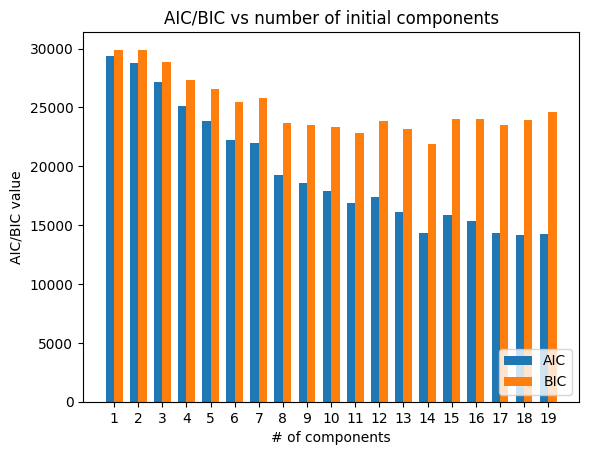

In [ ]:
diff_gmms = generate_gmms(diff_df)
plot_aic_bic_gmm_components(diff_gmms, diff_df)

With just one initialization per gmm, it was initially falling into local minima, but increasing it to 10 helped smooth the aic/bic curves. Also, the `reg_covar` parameter had to be tuned to the variance of the data, so the covariance matrices wouldn't become singular and falsely contribute to the model success.

It looks like 14 components is the way to go.

In [72]:
# display clusters for best GMM
best_components =14
best_gmm = diff_gmms[best_components - 1] # 14 components is best for diff_df
diff_labels = best_gmm.predict(diff_df)
for i in range(best_components):
    print(f"Cluster {i}:")
    print(diff_df.index[diff_labels == i].tolist())
    print()

Cluster 0:
['Anaheim', 'Atlantic_City', 'Denver', 'Fayetteville', 'Fort_Collins', 'Indianapolis', 'Lexington', 'Minneapolis', 'Omaha', 'Phoenix', 'Spokane', 'Syracuse', 'Tucson', 'Tulsa']

Cluster 1:
['Baton_Rouge', 'Bozeman', 'Casper', 'Flagstaff', 'Jackson', 'Lubbock', 'Punxsutawney']

Cluster 2:
['Cedar_Rapids', 'Green_Bay', 'Greensboro', 'Hot_Springs', 'Johnson_City', 'Savannah']

Cluster 3:
['Bangor', 'Grand_Junction', 'Raton']

Cluster 4:
['Asheville', 'Bellingham', 'Fort_Wayne', 'Salina']

Cluster 5:
['Alamosa']

Cluster 6:
['Charlottesville', 'Columbia', 'Forks', 'Hattiesburg', 'Keene', 'Rolla']

Cluster 7:
['Albuquerque', 'Bend', 'Jacksonville', 'Sarasota', 'St._George', 'Traverse_City']

Cluster 8:
['Allentown', 'Ann_Arbor', 'Burlington', 'Carlsbad', 'Destin', 'Eugene', 'Fargo', 'Hartford', 'Lansing', 'Madison', 'Portland', 'Providence', 'Reno', 'Santa_Barbara', 'St._Louis', 'Tacoma']

Cluster 9:
['Branson', 'Charleston', 'Mesquite', 'Pocatello', 'Wichita']

Cluster 10:
['Aus

I think that the ratio-based other dataframes will be less helpful here, but I'll try them anyway.

---
### Ratio bike to drive gmm components

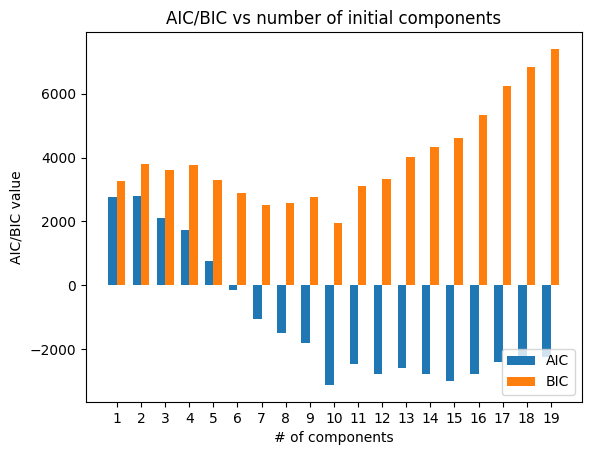

In [73]:
ratio_gmms = generate_gmms(ratio_df, reg_covar=1e-5)
plot_aic_bic_gmm_components(ratio_gmms, ratio_df)


The AIC cratering makes me suspicious that something unintended is happening. I'll still look at its clusters.

In [74]:
best_components =10
best_gmm = ratio_gmms[best_components - 1] # 14 components is best for diff_df
ratio_labels = best_gmm.predict(ratio_df)
for i in range(best_components):
    print(f"Cluster {i}:")
    print(ratio_df.index[ratio_labels == i].tolist())
    print()

Cluster 0:
['Bakersfield', 'Casper', 'Fort_Wayne', 'Green_Bay', 'Greensboro', 'Johnson_City', 'Peoria', 'Spokane', 'Wichita']

Cluster 1:
['Allentown', 'Ann_Arbor', 'Corvallis', 'Denver', 'Destin', 'Eugene', 'Madison', 'Portland', 'Reno', 'Sarasota', 'St._Louis', 'Tucson']

Cluster 2:
['Asheville', 'Austin', 'Bozeman', 'Cedar_Rapids', 'Dallas', 'Davis', 'Lubbock', 'Norfolk', 'Pocatello', 'Santa_Cruz']

Cluster 3:
['Albuquerque', 'Atlantic_City', 'Bend', 'Carbondale', 'Fayetteville', 'Ironton', 'Jacksonville', 'Syracuse']

Cluster 4:
['Flagstaff', 'Keene', 'St._George', 'Tulsa']

Cluster 5:
['Bangor', 'Baton_Rouge', 'Bellingham', 'Mesquite', 'Raton', 'San_Luis_Obispo']

Cluster 6:
['Anaheim', 'Duluth', 'Fort_Collins', 'Indianapolis', 'Lexington', 'Omaha']

Cluster 7:
['Akron', 'Charleston', 'Charlottesville', 'Chattanooga', 'Columbia', 'Dover', 'Forks', 'Hattiesburg', 'Huntsville', 'Rapid_City', 'Rolla']

Cluster 8:
['Albany', 'Baltimore', 'Boise', 'Burlington', 'Fargo', 'Hartford', 'Ha

A lot of these clusters seem somewhat random, and look very different to any of the kmeans or difference gmm. Let's do the difference/driving, see if that is anything different.

---
### Unlabeled Differences component analysis

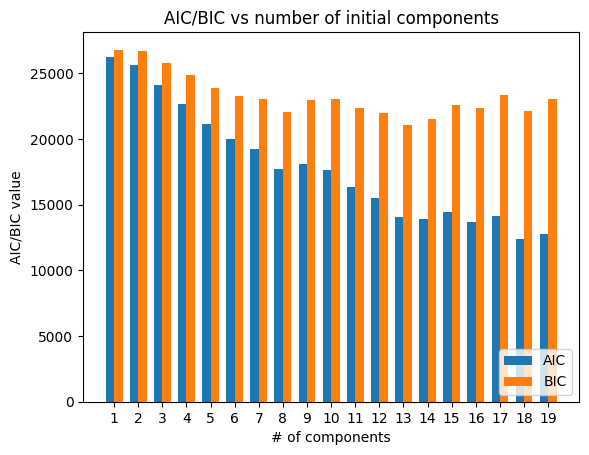

In [75]:
unlabeled_diff_gmms = generate_gmms(unlabeled_diff_df)
plot_aic_bic_gmm_components(unlabeled_diff_gmms, unlabeled_diff_df)

Looks like 13 components here.

In [76]:
best_components =8
best_gmm = unlabeled_diff_gmms[best_components - 1] # 14 components is best for diff_df
unlabeled_diff_labels = best_gmm.predict(unlabeled_diff_df)
for i in range(best_components):
    print(f"Cluster {i}:")
    print(unlabeled_diff_df.index[unlabeled_diff_labels == i].tolist())
    print()

Cluster 0:
['Albany', 'Allentown', 'Ann_Arbor', 'Baltimore', 'Boise', 'Burlington', 'Carlsbad', 'Corvallis', 'Destin', 'Duluth', 'Eugene', 'Fargo', 'Fayetteville', 'Hartford', 'Hayward', 'Kenosha', 'Lansing', 'Madison', 'Minneapolis', 'Omaha', 'Phoenix', 'Portland', 'Providence', 'Reno', 'Salt_Lake_City', 'Santa_Barbara', 'Spokane', 'St._Louis', 'Syracuse', 'Tacoma', 'Westchester', 'Wilmington']

Cluster 1:
['Charlottesville', 'Columbia', 'Forks', 'Hattiesburg', 'Keene', 'Rolla']

Cluster 2:
['Alamosa', 'Baton_Rouge', 'Bozeman', 'Casper', 'Flagstaff', 'Jackson', 'Lubbock', 'Punxsutawney']

Cluster 3:
['Austin', 'Cedar_Rapids', 'Dallas', 'Green_Bay', 'Greensboro', 'Hot_Springs', 'Huntsville', 'Ironton', 'Johnson_City', 'Norfolk', 'San_Luis_Obispo', 'Santa_Cruz', 'Worcester']

Cluster 4:
['Akron', 'Altoona', 'Bakersfield', 'Carbondale', 'Chattanooga', 'Dover', 'Peoria', 'Rapid_City', 'Savannah', 'Traverse_City']

Cluster 5:
['Asheville', 'Bellingham', 'Branson', 'Charleston', 'Fort_Wayne

It looks like the clusters here are similar to what we've seen with the other GMMs and the K-means clusters. 